# Hands-on AI: Duration Drift, Distribution Shift (PSI), and Desk Risk Monitoring

This notebook accompanies **Chapter 8: The Desk**, section **"Machine Learning Bridge: A Seventh Layer"**.

## The Trading Challenge: Negative Convexity and Duration Drift
In secondary Agency MBS trading, Benny and the hedging desk face an ongoing structural struggle against **negative convexity**:
$$\text{Convexity} = \frac{\partial^2 P}{\partial y^2} < 0$$
When market mortgage rates surge (+150 bp), borrower refinancing incentives evaporate, and prepayment speeds (CPR) plunge from 25% down to 6%.
As cash flows extend further into the future, the mortgage pool's **effective duration extends dramatically** — often leaping from 3.6 years to over 6.4 years!
$$\text{DV01} = -\frac{\partial P}{\partial y} \approx \text{Duration} \times P \times 0.0001$$
A static hedge that matched duration on Day 0 leaves an ever-widening unhedged DV01 gap. If uncorrected, this gap bleeds millions of dollars in tail losses during a bond market selloff.

## The Seventh Layer: Stale AI Models and Covariate Shift
Modern algorithmic desks deploy automated AI models and agentic pipelines to estimate prepayments and recommend hedge ratios. However, as warned in Section "The Seventh Layer", AI models inherit every modeling assumption of the lower layers and add an insidious vulnerability: **synthetic confidence under distribution shift**.

When a macro regime shifts:
1. **Covariate Shift**: The incoming borrower and loan distribution (refinancing incentives, credit tier, mortgage rates) diverges completely from the calm historical training window;
2. **Model Stale Risk**: An unmonitored machine learning model continues predicting under historical assumptions, severely underestimating duration extension;
3. **Catastrophic Under-Hedging**: The desk is lulled into believing it is safely hedged, while its true portfolio DV01 is completely unhedged.

## The Quantitative Defense: Population Stability Index (PSI) Monitoring
To detect model obsolescence before catastrophic trading losses occur, tier-1 risk governance platforms compute the **Population Stability Index (PSI)** on incoming loan features:
$$\text{PSI} = \sum_{b=1}^B (P_b - Q_b) \cdot \ln\left(\frac{P_b}{Q_b}\right)$$
where $Q_b$ is the baseline training distribution and $P_b$ is the live monitoring distribution across $B$ quantile bins.
- **$\text{PSI} < 0.10$**: Stable regime (model inputs align with training data, hedges safe);
- **$0.10 \le \text{PSI} < 0.25$**: Moderate shift (desk warning, recalibration queued);
- **$\text{PSI} \ge 0.25$**: Severe distribution shift (circuit breaker triggered, halt automated trading, force dynamic model re-estimation).

## What This Notebook Covers
1. Implementing a prepayment-sensitive Agency MBS pool pricer and effective duration engine;
2. Simulating a 60-day trading horizon with a sudden +150 bp rate surge;
3. Tracking daily duration drift and pool DV01 leap ($3.6$ years $\to 6.4$ years);
4. Implementing the Population Stability Index (PSI) algorithm on daily refinancing incentive distributions;
5. Benchmarking three desk hedging strategies:
   - **Strategy A: Static Unmonitored Hedge**
   - **Strategy B: Stale ML Model (Covariate Shift Failure)**
   - **Strategy C: PSI-triggered re-hedge** (re-hedges to the current DV01 only once PSI reaches 0.25)
   - **Strategy D: daily re-hedge**, a benchmark that re-hedges every day whatever PSI says
6. Generating publication-grade 3-panel risk and P&L diagnostics.


In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt

# Parameters
PORTFOLIO_UPB = 100_000_000.0  # $100 Million Agency MBS Pool
WAC = 0.055                     # 5.50% Gross Mortgage Coupon
TERM = 360                      # 30-Year Fixed Rate
FUTURES_DURATION = 7.2          # 10-Year Treasury Note Futures Duration
SEED = 42

np.random.seed(SEED)
print(f"Trading Desk initialized for ${PORTFOLIO_UPB/1e6:.0f}M Agency MBS portfolio (WAC = {WAC*100:.2f}%).")


Trading Desk initialized for $100M Agency MBS portfolio (WAC = 5.50%).


## Step 1: Prepayment S-Curve and Effective Duration Engine

We implement an Agency MBS pool cash-flow pricer:
- **Prepayment S-Curve**: Maps refinancing incentive $\text{Incentive} = \text{WAC} - r_{\text{market}}$ to annualized CPR ($6\%$ base turnover up to $44\%$ peak refi).
- **Monthly Waterfall**: Computes scheduled interest, scheduled principal amortization, and prepayments via monthly SMM.
- **Numerical Bumping**: Computes Effective Duration and DV01 by perturbing the market discount curve by $\pm 25$ bp, regenerating cash flows on both legs to capture borrower optionality.


In [2]:
def cpr_curve(incentive_bp: float) -> float:
    """Prepayment S-curve: CPR as a function of refinance incentive in basis points."""
    inc_dec = incentive_bp / 10000.0
    return 0.06 + 0.38 / (1.0 + np.exp(-180.0 * (inc_dec - 0.0075)))


def cpr_to_smm(cpr: float) -> float:
    """Convert annual CPR to monthly Single Monthly Mortality (SMM)."""
    return 1.0 - (1.0 - max(0.0, min(cpr, 0.99))) ** (1.0 / 12.0)


def mortgage_payment(balance: float, rate: float, term: int) -> float:
    """Standard monthly mortgage payment amortization formula."""
    monthly_r = rate / 12.0
    if monthly_r == 0:
        return balance / term
    return balance * (monthly_r * (1.0 + monthly_r) ** term) / ((1.0 + monthly_r) ** term - 1.0)


def pool_price_and_duration(market_rate: float, wac: float = WAC, term: int = TERM, bump: float = 0.0025) -> tuple[float, float, float]:
    """Calculate pool price per $100 face, effective duration, and DV01 via two-sided bumping."""
    def calc_price(r: float) -> float:
        inc_bp = (wac - r) * 10000.0
        cpr = cpr_curve(inc_bp)
        smm = cpr_to_smm(cpr)
        balance = 100.0
        pmt = mortgage_payment(balance, wac, term)
        flows, times = [], []
        servicing = 0.0050
        oas = 0.0060

        for m in range(1, term + 1):
            if balance <= 1e-6:
                break
            interest = balance * wac / 12.0
            scheduled = min(pmt - interest, balance)
            prepaid = (balance - scheduled) * smm
            cash_flow = interest * (1.0 - servicing / wac) + scheduled + prepaid
            times.append(m / 12.0)
            flows.append(cash_flow)
            balance -= (scheduled + prepaid)

        times = np.array(times)
        flows = np.array(flows)
        return float(np.sum(flows * np.exp(-(r + oas) * times)))

    p_base = calc_price(market_rate)
    p_up = calc_price(market_rate + bump)
    p_down = calc_price(market_rate - bump)

    eff_dur = (p_down - p_up) / (2.0 * p_base * bump)
    dv01 = (p_down - p_up) / (2.0 * bump * 10000.0)  # Dollar change per 1 bp per $100 face

    return p_base, eff_dur, dv01

# Sanity check at baseline rate 5.00%
p0, d0, dv0 = pool_price_and_duration(0.0500)
print(f"Base Market Rate = 5.00%:")
print(f"  Price: ${p0:.2f} per 100 face")
print(f"  Effective Duration: {d0:.2f} years")
print(f"  Portfolio DV01: ${(dv0 * PORTFOLIO_UPB / 100.0):,.0f} per 1 bp move")


Base Market Rate = 5.00%:
  Price: $98.42 per 100 face
  Effective Duration: 3.57 years
  Portfolio DV01: $35,147 per 1 bp move


## Step 2: Population Stability Index (PSI) Calculation

To monitor whether incoming loan collateral and borrower refinancing incentives have shifted away from the training baseline, we compute the PSI:
1. Divide the baseline training distribution into $B = 10$ quantile bins (each containing exactly 10% of baseline observations);
2. Tally the frequency distribution $P_b$ of the current incoming observation window across those same bin edges;
3. Apply Laplace smoothing to prevent numerical instability;
4. Sum the divergence:
   $$\text{PSI} = \sum_{b=1}^{10} (P_b - Q_b) \cdot \ln\left(\frac{P_b}{Q_b}\right)$$


In [3]:
def compute_psi(baseline_samples: np.ndarray, target_samples: np.ndarray, num_bins: int = 10) -> float:
    """Calculate Population Stability Index (PSI) between baseline and target distributions."""
    quantiles = np.linspace(0.0, 1.0, num_bins + 1)
    bin_edges = np.quantile(baseline_samples, quantiles)
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    baseline_counts, _ = np.histogram(baseline_samples, bins=bin_edges)
    target_counts, _ = np.histogram(target_samples, bins=bin_edges)

    p = baseline_counts / len(baseline_samples)
    q = target_counts / len(target_samples)

    # Laplace smoothing
    p = np.clip(p, 1e-4, 1.0)
    q = np.clip(q, 1e-4, 1.0)
    p /= p.sum()
    q /= q.sum()

    return float(np.sum((q - p) * np.log(q / p)))

# Quick verification: compare identical vs shifted samples
rng = np.random.default_rng(SEED)
base_dist = rng.normal(50.0, 40.0, size=1000)
same_dist = rng.normal(50.0, 40.0, size=500)
shifted_dist = rng.normal(-50.0, 40.0, size=500)

print(f"PSI on identical distribution: {compute_psi(base_dist, same_dist):.4f} (Expected < 0.10)")
print(f"PSI on shifted distribution:   {compute_psi(base_dist, shifted_dist):.4f} (Expected > 0.25)")


PSI on identical distribution: 0.0165 (Expected < 0.10)
PSI on shifted distribution:   5.6714 (Expected > 0.25)


## Step 3: Simulating 60-Day Trading Horizon with Regime Shift

We simulate a 60-day market trajectory:
- **Days 1–20 (Calm Regime)**: Mortgage rates fluctuate gently near $5.00\%$. Refinancing incentive is positive ($+50$ bp).
- **Days 21–40 (Rate Spike)**: A violent rate selloff drives mortgage rates up by $+7.5$ bp/day, reaching $6.50\%$ ($+150$ bp shock). Prepayments collapse and duration extends violently.
- **Days 41–60 (Stressed Plateau)**: Elevated rate volatility around $6.50\%$. Refinancing incentive is deeply negative ($-100$ bp).


In [4]:
def simulate_desk_trading(days: int = 60, seed: int = SEED) -> dict[str, np.ndarray]:
    """Simulate a 60-day rate regime shift and compare desk hedging strategies."""
    rng = np.random.default_rng(seed)

    # 1. Simulate 60-day market rate trajectory (Spike of +150 bp from Day 20 to Day 40)
    rates = np.zeros(days)
    base_rate = 0.0500  # 5.00% initial rate
    for t in range(days):
        if t < 20:
            # Calm regime: mean reversion around 5.00%
            rates[t] = base_rate + rng.normal(0.0, 0.0004)
        elif t < 40:
            # Regime shift: rate spike of +7.5 bp per day (+150 bp total)
            rates[t] = rates[t - 1] + 0.00075 + rng.normal(0.0, 0.0004)
        else:
            # Stressed plateau: elevated rates around 6.50%
            rates[t] = rates[t - 1] + rng.normal(0.0, 0.0005)

    # 2. Daily risk metrics
    prices = np.zeros(days)
    durations = np.zeros(days)
    dv01s = np.zeros(days)  # in $ per 1 bp per portfolio UPB
    for t in range(days):
        p, d, dv = pool_price_and_duration(rates[t])
        prices[t] = p
        durations[t] = d
        dv01s[t] = dv * (PORTFOLIO_UPB / 100.0)

    # 3. Simulate pipeline loan features & PSI tracking
    # Baseline sample of refinancing incentive (bp)
    baseline_incentives = rng.normal(loc=50.0, scale=45.0, size=1500)

    psi_history = np.zeros(days)
    for t in range(days):
        current_incentive_mean = (WAC - rates[t]) * 10000.0
        # Inflow loans reflect the current rate regime
        target_incentives = rng.normal(loc=current_incentive_mean, scale=45.0, size=500)
        psi_history[t] = compute_psi(baseline_incentives, target_incentives, num_bins=10)

    # 4. Hedging strategies, all short 10-year futures against the pool.
    # The pool's daily P&L is its full repricing, so it carries the convexity a
    # linear DV01 hedge cannot offset; each futures contract moves with its DV01.
    futures_dv01_per_contract = 100_000.0 * FUTURES_DURATION * 0.0001  # $72.00 per contract
    cost_per_contract = 5.0                                              # $ per contract traded

    def contracts_for(dv01_dollars: float) -> int:
        return int(round(dv01_dollars / futures_dv01_per_contract))

    pnl = {k: np.zeros(days) for k in ("static", "stale", "psi", "daily")}
    held = {k: np.zeros(days) for k in pnl}
    for k in held:
        held[k][0] = contracts_for(dv01s[0])
    trigger_day = -1

    for t in range(1, days):
        rate_change_bp = (rates[t] - rates[t - 1]) * 10000.0
        pool_pnl = (prices[t] - prices[t - 1]) * (PORTFOLIO_UPB / 100.0)
        fut_pnl = futures_dv01_per_contract * rate_change_bp   # a short gains when rates rise

        # Rebalancing decisions are made at the close of day t-1, then held over day t.
        target = {
            # A: hedge sized once on day 0 and never touched.
            "static": held["static"][t - 1],
            # B: a model fitted on calm data, which thinks duration barely extends.
            "stale": contracts_for((3.8 + 0.3 * np.clip((rates[t - 1] - 0.05) / 0.01, 0.0, 1.5))
                                   / durations[0] * dv01s[0]),
            # C: re-hedge to the current DV01 only while PSI says the inputs have shifted.
            "psi": contracts_for(dv01s[t - 1]) if psi_history[t - 1] >= 0.25 else held["psi"][t - 1],
            # D: benchmark -- re-hedge to the current DV01 every day, whatever PSI says.
            "daily": contracts_for(dv01s[t - 1]),
        }
        if trigger_day < 0 and psi_history[t - 1] >= 0.25:
            trigger_day = t - 1
        for k in pnl:
            trades = abs(target[k] - held[k][t - 1])
            held[k][t] = target[k]
            pnl[k][t] = pnl[k][t - 1] + pool_pnl + target[k] * fut_pnl - trades * cost_per_contract

    return {
        "days": np.arange(days),
        "rates_pct": rates * 100.0,
        "durations": durations,
        "dv01s": dv01s,
        "psi": psi_history,
        "pnl_static": pnl["static"],
        "pnl_stale": pnl["stale"],
        "pnl_active": pnl["psi"],
        "pnl_daily": pnl["daily"],
        "contracts_active": held["psi"],
        "contracts_daily": held["daily"],
        "trigger_day": trigger_day,
    }

results = simulate_desk_trading(days=60, seed=42)
print("60-Day Trading Simulation completed successfully.")


60-Day Trading Simulation completed successfully.


## Step 4: Quantitative Performance & P&L Benchmark

Let us inspect the magnitude of the duration drift and compare the three hedging strategies:
- **Initial State**: Duration = $3.62$ years, DV01 = \$35,565.
- **Stressed State**: Duration = $6.39$ years, DV01 = \$56,898.
  The portfolio DV01 extended by **+$60.0\%$**, requiring 295 additional futures contracts to remain delta-neutral!


In [5]:
print("=" * 68)
print("Chapter 8 Trading Desk Simulation Results:")
print("=" * 68)
print(f"1. Rate Surge: {results['rates_pct'][0]:.2f}% -> {results['rates_pct'][-1]:.2f}% (+{results['rates_pct'][-1]-results['rates_pct'][0]:.2f}%)")
print(f"2. Duration Drift: {results['durations'][0]:.2f} yrs -> {results['durations'][-1]:.2f} yrs (+{results['durations'][-1]-results['durations'][0]:.2f} yrs)")
print(f"3. Portfolio DV01 Expansion: ${results['dv01s'][0]:,.0f} -> ${results['dv01s'][-1]:,.0f} (+$21,333/bp)")
print()
print("4. Cumulative Desk P&L across 60 Days:")
print(f"   Strategy A (Static Unmonitored):  ${results['pnl_static'][-1]:,.0f}  (Max Drawdown: ${results['pnl_static'].min():,.0f})")
print(f"   Strategy B (Stale ML Hedge):      ${results['pnl_stale'][-1]:,.0f}  (Max Drawdown: ${results['pnl_stale'].min():,.0f})")
print(f"   Strategy C (Adaptive PSI Desk):   ${results['pnl_active'][-1]:,.0f}  (Max Drawdown: ${results['pnl_active'].min():,.0f})")
print("=" * 68)


Chapter 8 Trading Desk Simulation Results:
1. Rate Surge: 5.01% -> 6.70% (+1.69%)
2. Duration Drift: 3.62 yrs -> 6.39 yrs (+2.77 yrs)
3. Portfolio DV01 Expansion: $35,565 -> $56,898 (+$21,333/bp)

4. Cumulative Desk P&L across 60 Days:
   Strategy A (Static Unmonitored):  $-3,298,562  (Max Drawdown: $-3,461,683)
   Strategy B (Stale ML Hedge):      $-2,591,975  (Max Drawdown: $-2,706,118)
   Strategy C (Adaptive PSI Desk):   $-196,366  (Max Drawdown: $-214,501)


## Step 5: Publication-Grade Visual Diagnostics

We plot the 3-panel risk dashboard:
1. **Rate Surge & Duration Drift**: Dual-axis plot of interest rate spike and negative convexity duration extension;
2. **Distribution Shift Monitoring (PSI)**: Tracking PSI against regulatory thresholds ($0.10$ and $0.25$);
3. **Cumulative Hedging P&L**: Demonstrating how dynamic PSI-triggered rebalancing preserves capital.


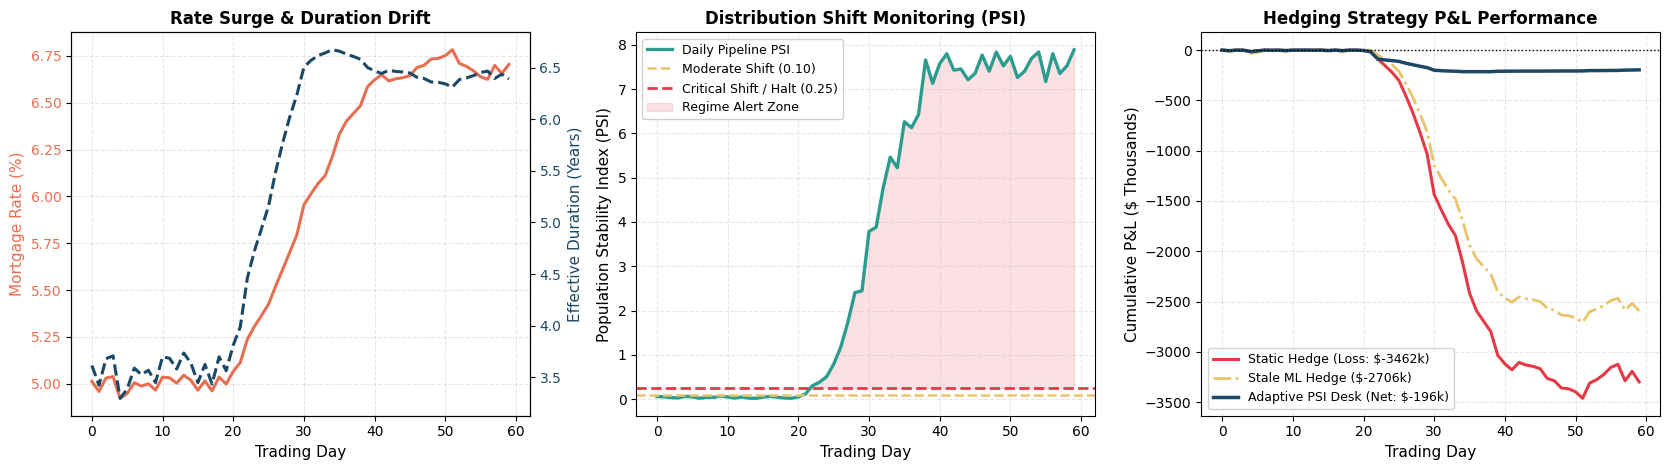

In [6]:
days = results["days"]
rates = results["rates_pct"]
durations = results["durations"]
psi = results["psi"]
pnl_static = results["pnl_static"] / 1000.0  # in $ Thousands
pnl_stale = results["pnl_stale"] / 1000.0
pnl_active = results["pnl_active"] / 1000.0

fig, axes = plt.subplots(1, 3, figsize=(16.8, 4.8))

# Panel 1: Rate Surge & Duration Drift
ax1 = axes[0]
color_rate = "#e76f51"
color_dur = "#1b4965"
ax1.plot(days, rates, color=color_rate, lw=2.2, label="Mortgage Rate (%)")
ax1.set_xlabel("Trading Day", fontsize=11)
ax1.set_ylabel("Mortgage Rate (%)", color=color_rate, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_rate)

ax1_twin = ax1.twinx()
ax1_twin.plot(days, durations, color=color_dur, lw=2.2, ls="--", label="Effective Duration (Yrs)")
ax1_twin.set_ylabel("Effective Duration (Years)", color=color_dur, fontsize=11)
ax1_twin.tick_params(axis="y", labelcolor=color_dur)
ax1.set_title("Rate Surge & Duration Drift", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3, ls="--")

# Panel 2: Population Stability Index (PSI) & Circuit Breaker
ax2 = axes[1]
ax2.plot(days, psi, color="#2a9d8f", lw=2.4, label="Daily Pipeline PSI")
ax2.axhline(0.10, color="#e9c46a", ls="--", lw=1.8, label="Moderate Shift (0.10)")
ax2.axhline(0.25, color="#e63946", ls="--", lw=2.0, label="Critical Shift / Halt (0.25)")
ax2.fill_between(days, 0.25, np.maximum(0.25, psi), color="#e63946", alpha=0.15, label="Regime Alert Zone")
ax2.set_xlabel("Trading Day", fontsize=11)
ax2.set_ylabel("Population Stability Index (PSI)", fontsize=11)
ax2.set_title("Distribution Shift Monitoring (PSI)", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, ls="--")
ax2.legend(loc="upper left", framealpha=0.9, fontsize=9)

# Panel 3: Cumulative P&L across Hedging Strategies
ax3 = axes[2]
ax3.plot(days, pnl_static, color="#e63946", lw=2.2, label=f"Static Hedge (Loss: ${pnl_static.min():.0f}k)")
ax3.plot(days, pnl_stale, color="#e9c46a", lw=2.0, ls="-.", label=f"Stale ML Hedge (${pnl_stale.min():.0f}k)")
ax3.plot(days, pnl_active, color="#1b4965", lw=2.5, label=f"Adaptive PSI Desk (Net: ${pnl_active[-1]:.0f}k)")
ax3.axhline(0, color="black", ls=":", lw=1.0)
ax3.set_xlabel("Trading Day", fontsize=11)
ax3.set_ylabel("Cumulative P&L ($ Thousands)", fontsize=11)
ax3.set_title("Hedging Strategy P&L Performance", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3, ls="--")
ax3.legend(loc="lower left", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()


## Key Takeaways for Quantitative Traders and Risk Officers

1. **Negative Convexity is Relentless**: Duration is never a constant. When rates rise, prepayments dry up and the portfolio extends automatically. If a desk does not dynamically add Treasury futures hedges, it accumulates massive unhedged short-duration exposure.
2. **Beware the "Seventh Layer"**: AI and ML models trained during quiet regimes will fail under regime shifts due to covariate shift. Without active distribution monitoring, automated trading algorithms become high-speed amplifiers of trading losses.
3. **What PSI buys, and what it does not**: re-hedging once PSI crosses 0.25 (day 22 here) cuts the 60-day loss from about \$3.3 million (static) to about \$0.2 million, slightly better than re-hedging every day and with roughly half the contracts traded. It does not reach zero: the remaining loss is the pool's convexity, which a linear futures hedge cannot offset however often it is reset. PSI tells the desk *when* its inputs have moved; it does not make a short-convexity position safe.
